# Here I will generate plots for my report.

### Showing support vectors

Support vectors:
 [[2. 0.]
 [4. 2.]
 [1. 1.]]


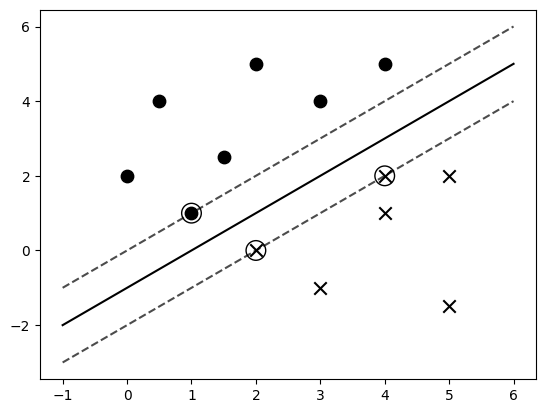

In [184]:
import numpy as np
from sklearn.svm import SVC
import sys, os
sys.path.append(os.path.abspath("..")) #need to do this to find src
import matplotlib.pyplot as plt

# Dataset I make
X = np.array([
    [2, 5],
    [1.5, 2.5],
    [3, 4],  
    [4, 5],
    [1, 1],
    [0.5, 4],
    [0,2],

    [2, 0],
    [4, 1],
    [4, 2], 
    [5, 2],
    [3, -1],
    [5, -1.5],
])

y = np.array([
    1, 1, 1, 1, 1, 1,1,
    -1, -1, -1, -1, -1, -1
])

# Initialize and train the detector
model = SVC(kernel="linear", C=1e6) #c to inf for hard margin classifier
model.fit(X, y)

# Support vectors
sv = model.support_vectors_
print("Support vectors:\n", sv)

# Scatter points
plt.scatter(X[y==1,0], X[y==1,1], marker='o', s=80, c='k')
plt.scatter(X[y==-1,0], X[y==-1,1], marker='x', s=80, c='k')
plt.scatter(sv[:,0], sv[:,1], s=200, facecolors='none', edgecolors='k', linewidths=1)

# Decision boundary and margins
w = model.coef_[0]
b = model.intercept_[0]

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
xx = np.linspace(x_min, x_max, 500)
yy = -(w[0]*xx + b)/w[1]

yy_margin_up = -(w[0]*xx + b - 1)/w[1]
yy_margin_down = -(w[0]*xx + b + 1)/w[1]

plt.plot(xx, yy, 'k-', label='Decision Boundary')
plt.plot(xx, yy_margin_up, 'k--', alpha=0.7)
plt.plot(xx, yy_margin_down, 'k--', alpha=0.7)

plt.show()

### Showing results of noisy data on hard margin classifier

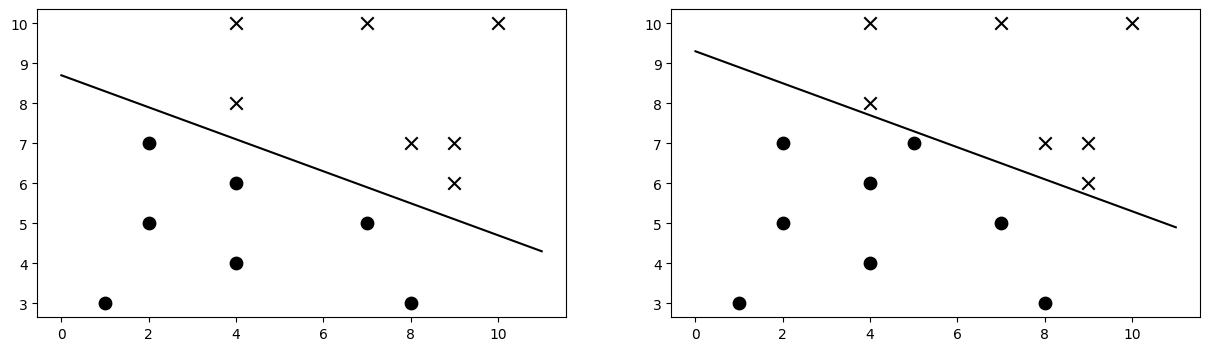

In [185]:
# Dataset from Succinctly textbook
X_1 = np.array([
    [1, 3],
    [2, 5],
    [2, 7],
    [4, 4],
    [4, 6],
    [7, 5],
    [8, 3],

    [4, 8], 
    [4, 10],
    [7, 10],
    [8, 7],
    [9, 6],
    [9, 7],
    [10,10]
])

y_1 = np.array([
    1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1, -1, -1, -1, -1
])

X_2 = np.array([
    [1, 3],
    [2, 5],
    [2, 7],
    [4, 4],
    [4, 6],
    [5, 7], #OUTLIER
    [7, 5],
    [8, 3],

    [4, 8], 
    [4, 10],
    [7, 10],
    [8, 7],
    [9, 6],
    [9, 7],
    [10,10]
])

y_2 = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1, -1, -1, -1, -1
])

x_min, x_max = X_2[:,0].min()-1, X_2[:,0].max()+1
xx = np.linspace(x_min, x_max, 500)

# SVM Stuff
#1
model1 = SVC(kernel="linear", C=1e6) #c to inf for hard margin classifier
model1.fit(X_1, y_1)
w_1 = model1.coef_[0]
b_1 = model1.intercept_[0]
yy_1 = -(w_1[0]*xx + b_1)/w_1[1]

#2
model2 = SVC(kernel="linear", C=1e6) #c to inf for hard margin classifier
model2.fit(X_2, y_2)
w_2 = model2.coef_[0]
b_2 = model2.intercept_[0]
yy_2 = -(w_2[0]*xx + b_2)/w_2[1]


#set up plot configuration
fig, ax = plt.subplots(1, 2, figsize=(15, 4)) # Adjust figsize for better layout

# Plot
ax[0].scatter(X_1[y_1==1,0], X_1[y_1==1,1], marker='o', s=80, c='k')
ax[0].scatter(X_1[y_1==-1,0], X_1[y_1==-1,1], marker='x', s=80, c='k')
ax[0].plot(xx, yy_1, 'k-', label='Decision Boundary')

ax[1].scatter(X_2[y_2==1,0], X_2[y_2==1,1], marker='o', s=80, c='k')
ax[1].scatter(X_2[y_2==-1,0], X_2[y_2==-1,1], marker='x', s=80, c='k')
ax[1].plot(xx, yy_2, 'k-', label='Decision Boundary')

plt.show()

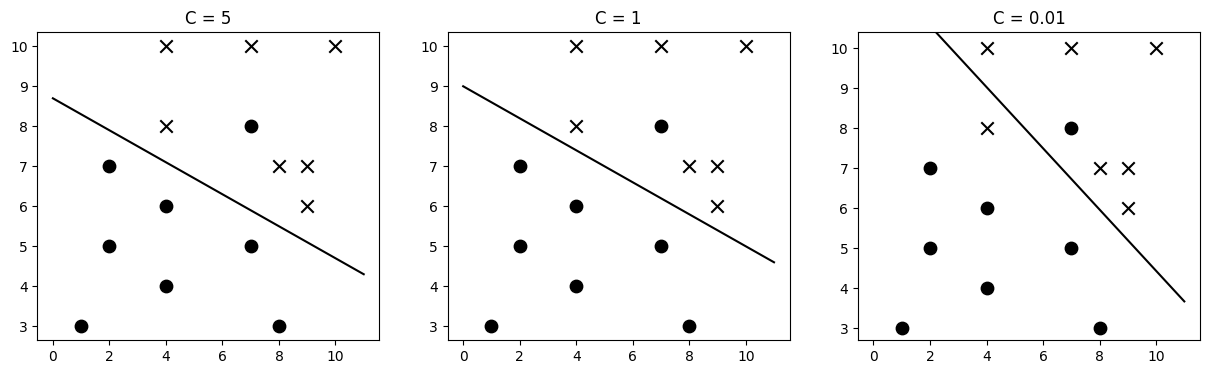

In [186]:
X_4 = np.array([
    [1, 3],
    [2, 5],
    [2, 7],
    [4, 4],
    [4, 6],
    [7, 8], #OUTLIER
    [7, 5],
    [8, 3],

    [4, 8], 
    [4, 10],
    [7, 10],
    [8, 7],
    [9, 6],
    [9, 7],
    [10,10]
])

y_4 = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1, -1, -1, -1, -1
])

# SVM Stuff -- varying C values, same data
model4 = SVC(kernel="linear", C=5) #c to inf for hard margin classifier
model4.fit(X_4, y_4)
w_4 = model4.coef_[0]
b_4 = model4.intercept_[0]
yy_4 = -(w_4[0]*xx + b_4)/w_4[1]

model5 = SVC(kernel="linear", C=1) #c to inf for hard margin classifier
model5.fit(X_4, y_4)
w_5 = model5.coef_[0]
b_5 = model5.intercept_[0]
yy_5 = -(w_5[0]*xx + b_5)/w_5[1]

model6 = SVC(kernel="linear", C=0.01) #c to inf for hard margin classifier
model6.fit(X_4, y_4)
w_6 = model6.coef_[0]
b_6 = model6.intercept_[0]
yy_6 = -(w_6[0]*xx + b_6)/w_6[1]


#set up plot configuration
fig, ax = plt.subplots(1, 3, figsize=(15, 4)) # Adjust figsize for better layout

# Plot
ax[0].scatter(X_4[y_4==1,0], X_4[y_4==1,1], marker='o', s=80, c='k')
ax[0].scatter(X_4[y_4==-1,0], X_4[y_4==-1,1], marker='x', s=80, c='k')

ax[1].scatter(X_4[y_4==1,0], X_4[y_4==1,1], marker='o', s=80, c='k')
ax[1].scatter(X_4[y_4==-1,0], X_4[y_4==-1,1], marker='x', s=80, c='k')

ax[2].scatter(X_4[y_4==1,0], X_4[y_4==1,1], marker='o', s=80, c='k')
ax[2].scatter(X_4[y_4==-1,0], X_4[y_4==-1,1], marker='x', s=80, c='k')

ax[0].plot(xx, yy_4, 'k-')
ax[1].plot(xx, yy_5, 'k-')
ax[2].plot(xx, yy_6, 'k-')

ax[2].set_ylim(2.7, 10.4)

ax[0].set_title("C = 5")
ax[1].set_title("C = 1")
ax[2].set_title("C = 0.01")

plt.show()

### Nonlinearly separable data

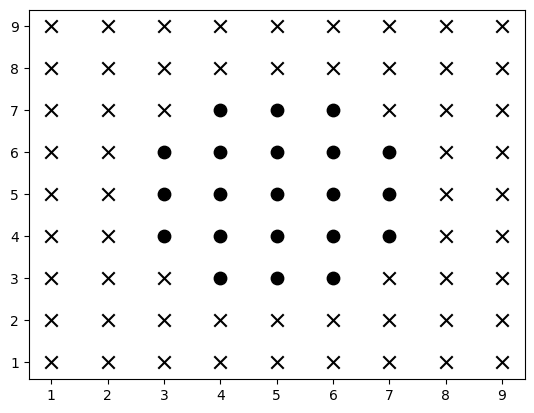

In [187]:
grid = np.array([
[1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [1, 7], [1, 8], [1, 9], 
[2, 1], [2, 2], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [2, 8], [2, 9], 
[3, 1], [3, 2], [3, 3], [3, 4], [3, 5], [3, 6], [3, 7], [3, 8], [3, 9], 
[4, 1], [4, 2], [4, 3], [4, 4], [4, 5], [4, 6], [4, 7], [4, 8], [4, 9], 
[5, 1], [5, 2], [5, 3], [5, 4], [5, 5], [5, 6], [5, 7], [5, 8], [5, 9], 
[6, 1], [6, 2], [6, 3], [6, 4], [6, 5], [6, 6], [6, 7], [6, 8], [6, 9], 
[7, 1], [7, 2], [7, 3], [7, 4], [7, 5], [7, 6], [7, 7], [7, 8], [7, 9],
[8, 1], [8, 2], [8, 3], [8, 4], [8, 5], [8, 6], [8, 7], [8, 8], [8, 9],
[9, 1], [9, 2], [9, 3], [9, 4], [9, 5], [9, 6], [9, 7], [9, 8], [9, 9],
])

circle_labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, -1, -1, -1, 1, 1, 1,
    1, 1, -1, -1, -1, -1, -1, 1, 1,
    1, 1, -1, -1, -1, -1, -1, 1, 1,
    1, 1, -1, -1, -1, -1, -1, 1, 1,
    1, 1, 1, -1, -1, -1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1,
])

plt.scatter(grid[circle_labels==1,0], grid[circle_labels==1,1], marker='x', s=80, c='k')
plt.scatter(grid[circle_labels==-1,0], grid[circle_labels==-1,1], marker='o', s=80, c='k')

plt.show()

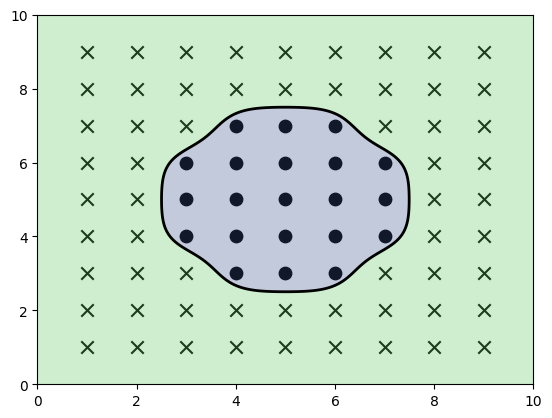

In [199]:
plt.scatter(grid[circle_labels==1,0], grid[circle_labels==1,1], marker='x', s=80, c='k')
plt.scatter(grid[circle_labels==-1,0], grid[circle_labels==-1,1], marker='o', s=80, c='k')

modelCirc = SVC(kernel="rbf", gamma=1.0)
modelCirc.fit(grid, circle_labels)

xxx, yyy = np.meshgrid(
    np.linspace(grid[:,0].min()-1, grid[:,0].max()+1, 500),
    np.linspace(grid[:,1].min()-1, grid[:,1].max()+1, 500)
)
grid_2 = np.c_[xxx.ravel(), yyy.ravel()]

# Predict on the grid
Z = modelCirc.decision_function(grid_2)
Z = Z.reshape(xxx.shape)

# Plot
plt.contourf(xxx, yyy, Z > 0, alpha=0.3)
plt.contour(xxx, yyy, Z, levels=[0], colors='k', linewidths=2)

plt.show()

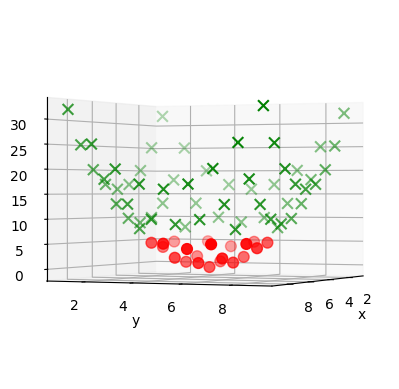

In [142]:
cx, cy = 5, 5
r2 = (grid[:,0] - cx)**2 + (grid[:,1] - cy)**2

X_lifted = np.c_[grid[:,0], grid[:,1], r2]
model_lifted = SVC(kernel="linear", C=1e6)
model_lifted.fit(X_lifted, circle_labels)

fig = plt.figure()#figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=0, azim=25)

ax.scatter(X_lifted[circle_labels==1,0], X_lifted[circle_labels==1,1], r2[circle_labels==1], marker='x', c='green', s=60)
ax.scatter(X_lifted[circle_labels==-1,0], X_lifted[circle_labels==-1,1], r2[circle_labels==-1], marker='o', c='red', s=60)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r²')

plt.show()

### Degree adjustments to polynomial kernel

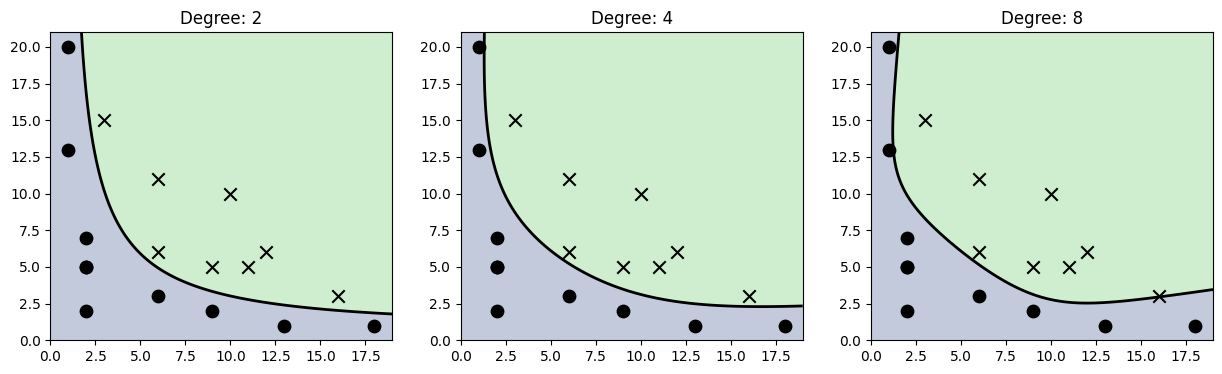

In [167]:
grid = np.array([ #inspired by dataset from Succinctly textbook, changed slightly
    [3, 15], [6, 6], [6, 11], [9, 5], [10, 10], [11, 5], [12, 6], [16, 3],

    [1, 20], [1, 13], [2, 5], [2, 5], [9, 2], [13, 1], [18, 1], [2, 2], [6, 3], [2, 7]
])

poly_labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1, -1, -1, -1, -1, -1, -1, -1

])

# SVM with different polynomial kernel degrees
deg2 = SVC(kernel='poly', degree = 2)
deg2.fit(grid, poly_labels)

deg4 = SVC(kernel='poly', degree = 4)
deg4.fit(grid, poly_labels)

deg8 = SVC(kernel='poly', degree = 8)
deg8.fit(grid, poly_labels)


xxx, yyy = np.meshgrid(
    np.linspace(grid[:,0].min()-1, grid[:,0].max()+1, 500),
    np.linspace(grid[:,1].min()-1, grid[:,1].max()+1, 500)
)
grid_2 = np.c_[xxx.ravel(), yyy.ravel()]

# Predict on the meshgrid
Z2 = deg2.decision_function(grid_2)
Z2 = Z2.reshape(xxx.shape)
Z4 = deg4.decision_function(grid_2)
Z4 = Z4.reshape(xxx.shape)
Z8 = deg8.decision_function(grid_2)
Z8 = Z8.reshape(xxx.shape)


#set up plot configuration
fig, ax = plt.subplots(1, 3, figsize=(15, 4)) # Adjust figsize for better layout

# Plot
ax[0].contourf(xxx, yyy, Z2 > 0, alpha=0.3)
ax[0].contour(xxx, yyy, Z2, levels=[0], colors='k', linewidths=2)
ax[1].contourf(xxx, yyy, Z4 > 0, alpha=0.3)
ax[1].contour(xxx, yyy, Z4, levels=[0], colors='k', linewidths=2)
ax[2].contourf(xxx, yyy, Z8 > 0, alpha=0.3)
ax[2].contour(xxx, yyy, Z8, levels=[0], colors='k', linewidths=2)

# Scatter plot data
ax[0].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[0].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')
ax[1].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[1].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')
ax[2].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[2].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')

ax[0].set_title("Degree: 2")
ax[1].set_title("Degree: 4")
ax[2].set_title("Degree: 8")
plt.show()


### Gamma varaition in RGF kernel

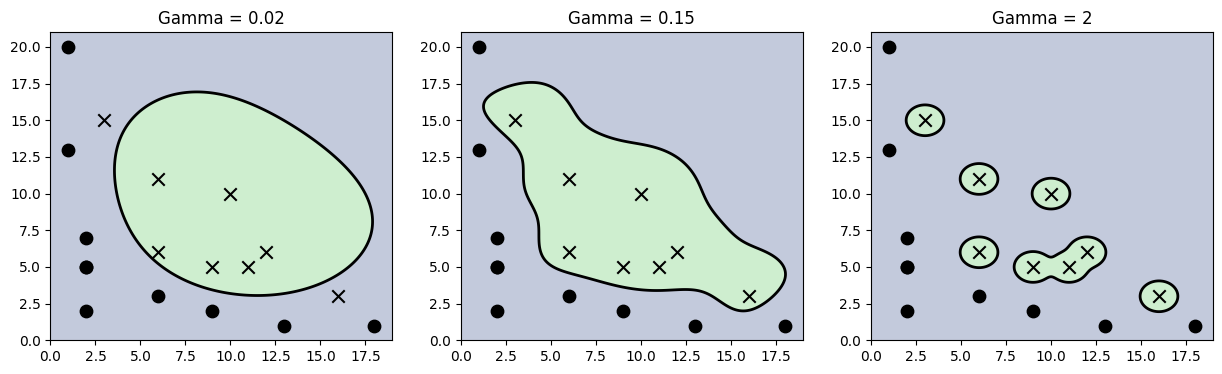

In [181]:
grid = np.array([ #inspired by dataset from Succinctly textbook, changed slightly
    [3, 15], [6, 6], [6, 11], [9, 5], [10, 10], [11, 5], [12, 6], [16, 3],

    [1, 20], [1, 13], [2, 5], [2, 5], [9, 2], [13, 1], [18, 1], [2, 2], [6, 3], [2, 7]
])

poly_labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1, -1, -1, -1, -1, -1, -1, -1

])

# SVM with different polynomial kernel degrees
deg2 = SVC(kernel='rbf', gamma=0.02)
deg2.fit(grid, poly_labels)

deg4 = SVC(kernel='rbf', gamma = 0.15)
deg4.fit(grid, poly_labels)

deg8 = SVC(kernel='rbf', gamma = 2)
deg8.fit(grid, poly_labels)


xxx, yyy = np.meshgrid(
    np.linspace(grid[:,0].min()-1, grid[:,0].max()+1, 500),
    np.linspace(grid[:,1].min()-1, grid[:,1].max()+1, 500)
)
grid_2 = np.c_[xxx.ravel(), yyy.ravel()]

# Predict on the meshgrid
Z2 = deg2.decision_function(grid_2)
Z2 = Z2.reshape(xxx.shape)
Z4 = deg4.decision_function(grid_2)
Z4 = Z4.reshape(xxx.shape)
Z8 = deg8.decision_function(grid_2)
Z8 = Z8.reshape(xxx.shape)


#set up plot configuration
fig, ax = plt.subplots(1, 3, figsize=(15, 4)) # Adjust figsize for better layout

# Plot
ax[0].contourf(xxx, yyy, Z2 > 0, alpha=0.3)
ax[0].contour(xxx, yyy, Z2, levels=[0], colors='k', linewidths=2)
ax[1].contourf(xxx, yyy, Z4 > 0, alpha=0.3)
ax[1].contour(xxx, yyy, Z4, levels=[0], colors='k', linewidths=2)
ax[2].contourf(xxx, yyy, Z8 > 0, alpha=0.3)
ax[2].contour(xxx, yyy, Z8, levels=[0], colors='k', linewidths=2)

# Scatter plot data
ax[0].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[0].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')
ax[1].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[1].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')
ax[2].scatter(grid[poly_labels==1,0], grid[poly_labels==1,1], marker='x', s=80, c='k')
ax[2].scatter(grid[poly_labels==-1,0], grid[poly_labels==-1,1], marker='o', s=80, c='k')

ax[0].set_title("Gamma = 0.02")
ax[1].set_title("Gamma = 0.15")
ax[2].set_title("Gamma = 2")
plt.show()
